In [1]:
print("Notebook is working")

Notebook is working


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [4]:
fear_greed_path = "../data/raw/fear_greed_index.csv"
historical_path = "../data/raw/historical_data.csv"

fg = pd.read_csv(fear_greed_path)
hist = pd.read_csv(historical_path)

print("Fear & Greed dataset loaded successfully")
print("Historical dataset loaded successfully")

Fear & Greed dataset loaded successfully
Historical dataset loaded successfully


In [5]:
print("Fear & Greed shape:", fg.shape)
print("Historical data shape:", hist.shape)

Fear & Greed shape: (2644, 4)
Historical data shape: (211224, 16)


In [6]:
print("Fear & Greed columns:")
print(fg.columns.tolist())

print("\nHistorical data columns:")
print(hist.columns.tolist())

Fear & Greed columns:
['timestamp', 'value', 'classification', 'date']

Historical data columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [7]:
print("Fear & Greed sample:")
display(fg.head())

print("Historical data sample:")
display(hist.head())

Fear & Greed sample:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Historical data sample:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
print("Missing values in Fear & Greed:")
print(fg.isnull().sum())

print("\nMissing values in Historical Data:")
print(hist.isnull().sum())

Missing values in Fear & Greed:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Historical Data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:
print("Duplicate rows in Fear & Greed:", fg.duplicated().sum())
print("Duplicate rows in Historical Data:", hist.duplicated().sum())

Duplicate rows in Fear & Greed: 0
Duplicate rows in Historical Data: 0


In [10]:
print("Fear & Greed data types:")
print(fg.dtypes)

print("\nHistorical data types:")
print(hist.dtypes)

Fear & Greed data types:
timestamp         int64
value             int64
classification      str
date                str
dtype: object

Historical data types:
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [11]:
print("Sentiment class counts:")
print(fg["classification"].value_counts())

Sentiment class counts:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


## Round 1 Summary — Data Loading and Initial Inspection

### Fear & Greed Dataset
- Shape: **(2644, 4)**
- Missing values: **0**
- Duplicate rows: **0**
- Sentiment classes found:
  - Fear
  - Greed
  - Extreme Fear
  - Neutral
  - Extreme Greed

### Historical Trader Dataset
- Shape: **(211224, 16)**
- Missing values: **0**
- Duplicate rows: **0**

### Key Observation
Both datasets loaded successfully and are clean at the surface level.  
The next step will be to convert timestamps properly and align both datasets by date for analysis.

In [12]:
fg_clean = fg.copy()
hist_clean = hist.copy()

print("Copies created successfully")

Copies created successfully


In [13]:
print("Fear & Greed timestamp sample:")
print(fg_clean[["timestamp", "date"]].head())

print("\nHistorical timestamp sample:")
print(hist_clean[["Timestamp IST", "Timestamp"]].head())

Fear & Greed timestamp sample:
    timestamp        date
0  1517463000  2018-02-01
1  1517549400  2018-02-02
2  1517635800  2018-02-03
3  1517722200  2018-02-04
4  1517808600  2018-02-05

Historical timestamp sample:
      Timestamp IST     Timestamp
0  02-12-2024 22:50  1.730000e+12
1  02-12-2024 22:50  1.730000e+12
2  02-12-2024 22:50  1.730000e+12
3  02-12-2024 22:50  1.730000e+12
4  02-12-2024 22:50  1.730000e+12


In [14]:
fg_clean["date"] = pd.to_datetime(fg_clean["date"])

print("Fear & Greed date converted successfully")
print(fg_clean["date"].dtype)

Fear & Greed date converted successfully
datetime64[us]


In [15]:
print(fg_clean[["date"]].head())
print("\nEarliest Fear & Greed date:", fg_clean["date"].min())
print("Latest Fear & Greed date:", fg_clean["date"].max())

        date
0 2018-02-01
1 2018-02-02
2 2018-02-03
3 2018-02-04
4 2018-02-05

Earliest Fear & Greed date: 2018-02-01 00:00:00
Latest Fear & Greed date: 2025-05-02 00:00:00


In [16]:
hist_clean["Timestamp_converted"] = pd.to_datetime(hist_clean["Timestamp"], unit="ms")

print("Historical Timestamp converted successfully")
print(hist_clean["Timestamp_converted"].dtype)

Historical Timestamp converted successfully
datetime64[ms]


In [17]:
print(hist_clean[["Timestamp", "Timestamp_converted"]].head())

print("\nEarliest historical timestamp:", hist_clean["Timestamp_converted"].min())
print("Latest historical timestamp:", hist_clean["Timestamp_converted"].max())

      Timestamp Timestamp_converted
0  1.730000e+12 2024-10-27 03:33:20
1  1.730000e+12 2024-10-27 03:33:20
2  1.730000e+12 2024-10-27 03:33:20
3  1.730000e+12 2024-10-27 03:33:20
4  1.730000e+12 2024-10-27 03:33:20

Earliest historical timestamp: 2023-03-28 10:40:00
Latest historical timestamp: 2025-06-15 15:06:40


In [18]:
fg_clean["date_only"] = fg_clean["date"].dt.date
hist_clean["date_only"] = hist_clean["Timestamp_converted"].dt.date

print("Date-only columns created successfully")

Date-only columns created successfully


In [19]:
print("Fear & Greed date_only sample:")
print(fg_clean[["date", "date_only"]].head())

print("\nHistorical date_only sample:")
print(hist_clean[["Timestamp_converted", "date_only"]].head())


Fear & Greed date_only sample:
        date   date_only
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05

Historical date_only sample:
  Timestamp_converted   date_only
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27


In [20]:
print("Fear & Greed date range:")
print("Start:", fg_clean["date_only"].min())
print("End  :", fg_clean["date_only"].max())

print("\nHistorical data date range:")
print("Start:", hist_clean["date_only"].min())
print("End  :", hist_clean["date_only"].max())

Fear & Greed date range:
Start: 2018-02-01
End  : 2025-05-02

Historical data date range:
Start: 2023-03-28
End  : 2025-06-15


In [21]:
print("Unique dates in Fear & Greed dataset:", fg_clean["date_only"].nunique())
print("Unique dates in Historical dataset:", hist_clean["date_only"].nunique())

Unique dates in Fear & Greed dataset: 2644
Unique dates in Historical dataset: 7


In [22]:
fg_dates = set(fg_clean["date_only"].unique())
hist_dates = set(hist_clean["date_only"].unique())

common_dates = fg_dates.intersection(hist_dates)

print("Number of common dates:", len(common_dates))

Number of common dates: 6


In [23]:
fg_aligned = fg_clean[fg_clean["date_only"].isin(common_dates)].copy()
hist_aligned = hist_clean[hist_clean["date_only"].isin(common_dates)].copy()

print("Aligned Fear & Greed shape:", fg_aligned.shape)
print("Aligned Historical shape:", hist_aligned.shape)

Aligned Fear & Greed shape: (6, 5)
Aligned Historical shape: (184263, 18)


In [24]:
print("Aligned Fear & Greed date range:")
print("Start:", fg_aligned["date_only"].min())
print("End  :", fg_aligned["date_only"].max())

print("\nAligned Historical date range:")
print("Start:", hist_aligned["date_only"].min())
print("End  :", hist_aligned["date_only"].max())

Aligned Fear & Greed date range:
Start: 2023-03-28
End  : 2025-02-19

Aligned Historical date range:
Start: 2023-03-28
End  : 2025-02-19


In [25]:
fg_date_counts = fg_aligned["date_only"].value_counts()

print("Maximum rows for a single date in Fear & Greed:", fg_date_counts.max())
print("Number of dates having more than 1 row:", (fg_date_counts > 1).sum())

Maximum rows for a single date in Fear & Greed: 1
Number of dates having more than 1 row: 0


In [26]:
sentiment_daily = fg_aligned[["date_only", "classification"]].copy()

print("Daily sentiment table created")
print(sentiment_daily.head())

Daily sentiment table created
       date_only classification
1878  2023-03-28          Greed
2109  2023-11-14          Greed
2225  2024-03-09  Extreme Greed
2341  2024-07-03        Neutral
2456  2024-10-27          Greed


In [27]:
sentiment_daily["sentiment_group"] = sentiment_daily["classification"].replace({
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Extreme Greed": "Greed",
    "Greed": "Greed",
    "Neutral": "Neutral"
})

print("Sentiment group column created")
print(sentiment_daily.head())

Sentiment group column created
       date_only classification sentiment_group
1878  2023-03-28          Greed           Greed
2109  2023-11-14          Greed           Greed
2225  2024-03-09  Extreme Greed           Greed
2341  2024-07-03        Neutral         Neutral
2456  2024-10-27          Greed           Greed


In [28]:
print("Grouped sentiment counts:")
print(sentiment_daily["sentiment_group"].value_counts())

Grouped sentiment counts:
sentiment_group
Greed      4
Neutral    1
Fear       1
Name: count, dtype: int64


In [29]:
print("Rows in sentiment_daily:", len(sentiment_daily))
print("\nSentiment table preview:")
print(sentiment_daily)

Rows in sentiment_daily: 6

Sentiment table preview:
       date_only classification sentiment_group
1878  2023-03-28          Greed           Greed
2109  2023-11-14          Greed           Greed
2225  2024-03-09  Extreme Greed           Greed
2341  2024-07-03        Neutral         Neutral
2456  2024-10-27          Greed           Greed
2571  2025-02-19           Fear            Fear


## Round 2 Summary — Timestamp Conversion and Date Alignment

### Work completed
- Created safe working copies of both datasets
- Converted the Fear & Greed `date` column to proper datetime format
- Converted the historical `Timestamp` column to proper datetime format
- Created a `date_only` column in both datasets for daily-level analysis
- Identified the common dates shared by both datasets
- Filtered both datasets to only overlapping dates
- Created a clean daily sentiment table
- Created a grouped sentiment column:
  - Fear = Fear + Extreme Fear
  - Greed = Greed + Extreme Greed
  - Neutral = Neutral

### Key Observation
Both datasets are now aligned at the daily level.  
However, the overlapping time window between the sentiment data and historical trader data is limited, so the analysis will be based only on the common dates available in both datasets.

In [30]:
print("Relevant trading columns sample:")
display(
    hist_aligned[
        [
            "Account",
            "Coin",
            "Execution Price",
            "Size Tokens",
            "Size USD",
            "Side",
            "Direction",
            "Closed PnL",
            "Fee",
            "date_only"
        ]
    ].head(10)
)

Relevant trading columns sample:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Direction,Closed PnL,Fee,date_only
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,Buy,0.0,0.345404,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,Buy,0.0,0.005600,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,Buy,0.0,0.050431,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,Buy,0.0,0.050043,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,Buy,0.0,0.003055,2024-10-27
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,Buy,0.0,0.000493,2024-10-27
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,Buy,0.0,0.050431,2024-10-27
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,Buy,0.0,0.011900,2024-10-27
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,Buy,0.0,0.016100,2024-10-27
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,Buy,0.0,0.004375,2024-10-27


In [31]:
print(
    hist_aligned[
        [
            "Execution Price",
            "Size Tokens",
            "Size USD",
            "Closed PnL",
            "Fee",
            "Side",
            "Direction"
        ]
    ].dtypes
)

Execution Price    float64
Size Tokens        float64
Size USD           float64
Closed PnL         float64
Fee                float64
Side                   str
Direction              str
dtype: object


In [32]:
print("Unique values in Side:")
print(hist_aligned["Side"].unique())

print("\nUnique values in Direction:")
print(hist_aligned["Direction"].unique())

Unique values in Side:
<StringArray>
['BUY', 'SELL']
Length: 2, dtype: str

Unique values in Direction:
<StringArray>
['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion', 'Open Short', 'Close Short', 'Long > Short', 'Short > Long', 'Auto-Deleveraging', 'Settlement']
Length: 11, dtype: str


In [33]:
print("Side value counts:")
print(hist_aligned["Side"].value_counts())

print("\nDirection value counts:")
print(hist_aligned["Direction"].value_counts())

Side value counts:
Side
SELL    95885
BUY     88378
Name: count, dtype: int64

Direction value counts:
Direction
Open Long               45564
Close Long              44935
Open Short              32861
Close Short             28091
Sell                    17890
Buy                     14657
Spot Dust Conversion      137
Short > Long               65
Long > Short               54
Auto-Deleveraging           8
Settlement                  1
Name: count, dtype: int64


In [34]:
print("Closed PnL summary:")
print(hist_aligned["Closed PnL"].describe())

print("\nMinimum Closed PnL:", hist_aligned["Closed PnL"].min())
print("Maximum Closed PnL:", hist_aligned["Closed PnL"].max())

Closed PnL summary:
count    184263.000000
mean         55.492690
std         937.857954
min     -117990.104100
25%           0.000000
50%           0.000000
75%           6.602400
max      135329.090100
Name: Closed PnL, dtype: float64

Minimum Closed PnL: -117990.1041
Maximum Closed PnL: 135329.0901


In [35]:
hist_aligned["is_win"] = (hist_aligned["Closed PnL"] > 0).astype(int)

print("is_win column created successfully")
print(hist_aligned[["Closed PnL", "is_win"]].head(10))

is_win column created successfully
   Closed PnL  is_win
0         0.0       0
1         0.0       0
2         0.0       0
3         0.0       0
4         0.0       0
5         0.0       0
6         0.0       0
7         0.0       0
8         0.0       0
9         0.0       0


In [36]:
hist_aligned["position_type"] = hist_aligned["Direction"].astype(str).str.strip().str.lower()

print("position_type column created successfully")
print(hist_aligned[["Direction", "position_type"]].head(10))

position_type column created successfully
  Direction position_type
0       Buy           buy
1       Buy           buy
2       Buy           buy
3       Buy           buy
4       Buy           buy
5       Buy           buy
6       Buy           buy
7       Buy           buy
8       Buy           buy
9       Buy           buy


In [37]:
print("Unique values in position_type:")
print(hist_aligned["position_type"].unique())

print("\nCounts of position_type:")
print(hist_aligned["position_type"].value_counts())

Unique values in position_type:
<StringArray>
['buy', 'sell', 'open long', 'close long', 'spot dust conversion', 'open short', 'close short', 'long > short', 'short > long', 'auto-deleveraging', 'settlement']
Length: 11, dtype: str

Counts of position_type:
position_type
open long               45564
close long              44935
open short              32861
close short             28091
sell                    17890
buy                     14657
spot dust conversion      137
short > long               65
long > short               54
auto-deleveraging           8
settlement                  1
Name: count, dtype: int64


In [38]:
daily_metrics = (
    hist_aligned.groupby("date_only")
    .agg(
        total_daily_pnl=("Closed PnL", "sum"),
        avg_pnl_per_trade=("Closed PnL", "mean"),
        win_rate=("is_win", "mean"),
        avg_trade_size_usd=("Size USD", "mean"),
        avg_execution_price=("Execution Price", "mean"),
        avg_fee=("Fee", "mean"),
        trades_per_day=("Closed PnL", "count")
    )
    .reset_index()
)

print("Daily metrics table created successfully")
display(daily_metrics)

Daily metrics table created successfully


,date_only,total_daily_pnl,avg_pnl_per_trade,win_rate,avg_trade_size_usd,avg_execution_price,avg_fee,trades_per_day
0,2023-03-28,0.000000e+00,0.000000,0.000000,159.000000,1898.133333,0.000000,3
1,2023-11-14,1.555034e+02,0.148807,0.274641,11057.827522,10454.871036,2.674230,1045
2,2024-03-09,1.769655e+05,25.418772,0.490089,5660.265764,9771.897315,0.978567,6962
3,2024-07-03,1.587424e+05,22.229713,0.317182,3058.848110,2663.132338,1.224461,7141
4,2024-10-27,3.189461e+06,90.504272,0.451605,2949.625864,5367.503277,0.611205,35241
5,2025-02-19,6.699925e+06,50.047622,0.415146,5259.977837,11102.057978,1.083267,133871


In [39]:
buy_sell_daily = (
    hist_aligned.groupby(["date_only", "position_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print("Buy/sell daily table created successfully")
display(buy_sell_daily)

Buy/sell daily table created successfully


position_type,date_only,auto-deleveraging,buy,close long,close short,long > short,open long,open short,sell,settlement,short > long,spot dust conversion
0,2023-03-28,0,0,0,0,0,3,0,0,0,0,0
1,2023-11-14,0,0,380,103,0,388,174,0,0,0,0
2,2024-03-09,0,88,2389,1931,13,1339,1114,75,0,13,0
3,2024-07-03,8,786,886,1799,0,918,2389,295,0,2,58
4,2024-10-27,0,5806,4725,4026,5,5088,5712,9833,0,7,39
5,2025-02-19,0,7977,36555,20232,36,37828,23472,7687,1,43,40


In [40]:
buy_sell_daily = buy_sell_daily.rename(columns={
    "buy": "buy_trades",
    "sell": "sell_trades"
})

print("Buy/sell columns renamed successfully")
display(buy_sell_daily)

Buy/sell columns renamed successfully


position_type,date_only,auto-deleveraging,buy_trades,close long,close short,long > short,open long,open short,sell_trades,settlement,short > long,spot dust conversion
0,2023-03-28,0,0,0,0,0,3,0,0,0,0,0
1,2023-11-14,0,0,380,103,0,388,174,0,0,0,0
2,2024-03-09,0,88,2389,1931,13,1339,1114,75,0,13,0
3,2024-07-03,8,786,886,1799,0,918,2389,295,0,2,58
4,2024-10-27,0,5806,4725,4026,5,5088,5712,9833,0,7,39
5,2025-02-19,0,7977,36555,20232,36,37828,23472,7687,1,43,40


In [41]:
daily_features = pd.merge(
    daily_metrics,
    buy_sell_daily,
    on="date_only",
    how="left"
)

print("Daily features table created successfully")
display(daily_features)

Daily features table created successfully


,date_only,total_daily_pnl,avg_pnl_per_trade,win_rate,avg_trade_size_usd,avg_execution_price,avg_fee,trades_per_day,auto-deleveraging,buy_trades,close long,close short,long > short,open long,open short,sell_trades,settlement,short > long,spot dust conversion
0,2023-03-28,0.000000e+00,0.000000,0.000000,159.000000,1898.133333,0.000000,3,0,0,0,0,0,3,0,0,0,0,0
1,2023-11-14,1.555034e+02,0.148807,0.274641,11057.827522,10454.871036,2.674230,1045,0,0,380,103,0,388,174,0,0,0,0
2,2024-03-09,1.769655e+05,25.418772,0.490089,5660.265764,9771.897315,0.978567,6962,0,88,2389,1931,13,1339,1114,75,0,13,0
3,2024-07-03,1.587424e+05,22.229713,0.317182,3058.848110,2663.132338,1.224461,7141,8,786,886,1799,0,918,2389,295,0,2,58
4,2024-10-27,3.189461e+06,90.504272,0.451605,2949.625864,5367.503277,0.611205,35241,0,5806,4725,4026,5,5088,5712,9833,0,7,39
5,2025-02-19,6.699925e+06,50.047622,0.415146,5259.977837,11102.057978,1.083267,133871,0,7977,36555,20232,36,37828,23472,7687,1,43,40


In [42]:
daily_features["buy_sell_ratio"] = daily_features["buy_trades"] / daily_features["sell_trades"].replace(0, np.nan)

print("buy_sell_ratio column created successfully")
display(daily_features[["date_only", "buy_trades", "sell_trades", "buy_sell_ratio"]])

buy_sell_ratio column created successfully


,date_only,buy_trades,sell_trades,buy_sell_ratio
0,2023-03-28,0,0,NaN
1,2023-11-14,0,0,NaN
2,2024-03-09,88,75,1.173333
3,2024-07-03,786,295,2.664407
4,2024-10-27,5806,9833,0.590461
5,2025-02-19,7977,7687,1.037726


In [43]:
analysis_df = pd.merge(
    daily_features,
    sentiment_daily,
    on="date_only",
    how="left"
)

print("Final analysis table created successfully")
display(analysis_df)

Final analysis table created successfully


,date_only,total_daily_pnl,avg_pnl_per_trade,win_rate,avg_trade_size_usd,avg_execution_price,avg_fee,trades_per_day,auto-deleveraging,buy_trades,close long,close short,long > short,open long,open short,sell_trades,settlement,short > long,spot dust conversion,buy_sell_ratio,classification,sentiment_group
0,2023-03-28,0.000000e+00,0.000000,0.000000,159.000000,1898.133333,0.000000,3,0,0,0,0,0,3,0,0,0,0,0,NaN,Greed,Greed
1,2023-11-14,1.555034e+02,0.148807,0.274641,11057.827522,10454.871036,2.674230,1045,0,0,380,103,0,388,174,0,0,0,0,NaN,Greed,Greed
2,2024-03-09,1.769655e+05,25.418772,0.490089,5660.265764,9771.897315,0.978567,6962,0,88,2389,1931,13,1339,1114,75,0,13,0,1.173333,Extreme Greed,Greed
3,2024-07-03,1.587424e+05,22.229713,0.317182,3058.848110,2663.132338,1.224461,7141,8,786,886,1799,0,918,2389,295,0,2,58,2.664407,Neutral,Neutral
4,2024-10-27,3.189461e+06,90.504272,0.451605,2949.625864,5367.503277,0.611205,35241,0,5806,4725,4026,5,5088,5712,9833,0,7,39,0.590461,Greed,Greed
5,2025-02-19,6.699925e+06,50.047622,0.415146,5259.977837,11102.057978,1.083267,133871,0,7977,36555,20232,36,37828,23472,7687,1,43,40,1.037726,Fear,Fear


In [44]:
print("analysis_df shape:", analysis_df.shape)

print("\nanalysis_df columns:")
print(analysis_df.columns.tolist())

analysis_df shape: (6, 22)

analysis_df columns:
['date_only', 'total_daily_pnl', 'avg_pnl_per_trade', 'win_rate', 'avg_trade_size_usd', 'avg_execution_price', 'avg_fee', 'trades_per_day', 'auto-deleveraging', 'buy_trades', 'close long', 'close short', 'long > short', 'open long', 'open short', 'sell_trades', 'settlement', 'short > long', 'spot dust conversion', 'buy_sell_ratio', 'classification', 'sentiment_group']


In [45]:
print("Missing values in analysis_df:")
print(analysis_df.isnull().sum())

Missing values in analysis_df:
date_only               0
total_daily_pnl         0
avg_pnl_per_trade       0
win_rate                0
avg_trade_size_usd      0
avg_execution_price     0
avg_fee                 0
trades_per_day          0
auto-deleveraging       0
buy_trades              0
close long              0
close short             0
long > short            0
open long               0
open short              0
sell_trades             0
settlement              0
short > long            0
spot dust conversion    0
buy_sell_ratio          2
classification          0
sentiment_group         0
dtype: int64


In [46]:
print("Final analysis table preview:")
display(analysis_df.head(10))

Final analysis table preview:


,date_only,total_daily_pnl,avg_pnl_per_trade,win_rate,avg_trade_size_usd,avg_execution_price,avg_fee,trades_per_day,auto-deleveraging,buy_trades,close long,close short,long > short,open long,open short,sell_trades,settlement,short > long,spot dust conversion,buy_sell_ratio,classification,sentiment_group
0,2023-03-28,0.000000e+00,0.000000,0.000000,159.000000,1898.133333,0.000000,3,0,0,0,0,0,3,0,0,0,0,0,NaN,Greed,Greed
1,2023-11-14,1.555034e+02,0.148807,0.274641,11057.827522,10454.871036,2.674230,1045,0,0,380,103,0,388,174,0,0,0,0,NaN,Greed,Greed
2,2024-03-09,1.769655e+05,25.418772,0.490089,5660.265764,9771.897315,0.978567,6962,0,88,2389,1931,13,1339,1114,75,0,13,0,1.173333,Extreme Greed,Greed
3,2024-07-03,1.587424e+05,22.229713,0.317182,3058.848110,2663.132338,1.224461,7141,8,786,886,1799,0,918,2389,295,0,2,58,2.664407,Neutral,Neutral
4,2024-10-27,3.189461e+06,90.504272,0.451605,2949.625864,5367.503277,0.611205,35241,0,5806,4725,4026,5,5088,5712,9833,0,7,39,0.590461,Greed,Greed
5,2025-02-19,6.699925e+06,50.047622,0.415146,5259.977837,11102.057978,1.083267,133871,0,7977,36555,20232,36,37828,23472,7687,1,43,40,1.037726,Fear,Fear


## Round 3 Summary — Feature Engineering

### Work completed
- Inspected the key trading columns needed for analysis
- Verified the data types of the main numeric and categorical trading fields
- Examined the `Side` and `Direction` values used in the trading dataset
- Confirmed that `Closed PnL` contains both profit and loss values
- Created a trade-level `is_win` flag
- Created a cleaned `position_type` field from the direction information
- Built a daily metrics table containing:
  - total daily PnL
  - average PnL per trade
  - win rate
  - average trade size in USD
  - average execution price
  - average fee
  - number of trades per day
- Built daily buy/sell counts
- Created a buy/sell ratio
- Merged the daily features with daily sentiment labels to create the final analysis table

### Key Observation
A clean day-level analysis table is now ready.  
Each row represents one date and contains both trading-performance metrics and sentiment labels, which allows direct comparison of trader behavior under different market sentiment conditions.

In [47]:
print("Days per sentiment group in analysis_df:")
print(analysis_df["sentiment_group"].value_counts())

Days per sentiment group in analysis_df:
sentiment_group
Greed      4
Neutral    1
Fear       1
Name: count, dtype: int64


In [48]:
performance_by_sentiment = (
    analysis_df.groupby("sentiment_group")[[
        "total_daily_pnl",
        "avg_pnl_per_trade",
        "win_rate",
        "trades_per_day"
    ]]
    .mean()
    .round(4)
)

print("Performance summary by sentiment group:")
display(performance_by_sentiment)

Performance summary by sentiment group:


,total_daily_pnl,avg_pnl_per_trade,win_rate,trades_per_day
sentiment_group,,,,
Fear,6.699925e+06,50.0476,0.4151,133871.00
Greed,8.416455e+05,29.0180,0.3041,10812.75
Neutral,1.587424e+05,22.2297,0.3172,7141.00


In [49]:
behavior_by_sentiment = (
    analysis_df.groupby("sentiment_group")[[
        "avg_trade_size_usd",
        "avg_fee",
        "buy_trades",
        "sell_trades",
        "buy_sell_ratio"
    ]]
    .mean()
    .round(4)
)

print("Behavior summary by sentiment group:")
display(behavior_by_sentiment)

Behavior summary by sentiment group:


,avg_trade_size_usd,avg_fee,buy_trades,sell_trades,buy_sell_ratio
sentiment_group,,,,,
Fear,5259.9778,1.0833,7977.0,7687.0,1.0377
Greed,4956.6798,1.0660,1473.5,2477.0,0.8819
Neutral,3058.8481,1.2245,786.0,295.0,2.6644


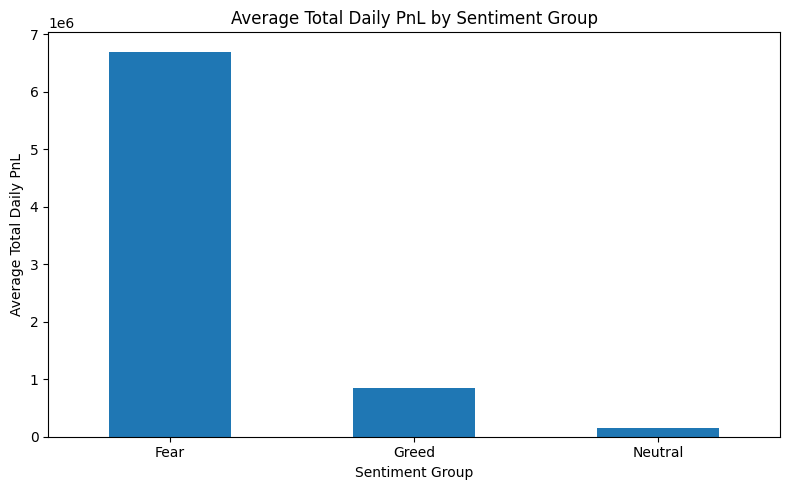

In [50]:
plt.figure(figsize=(8, 5))
performance_by_sentiment["total_daily_pnl"].plot(kind="bar")

plt.title("Average Total Daily PnL by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Total Daily PnL")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

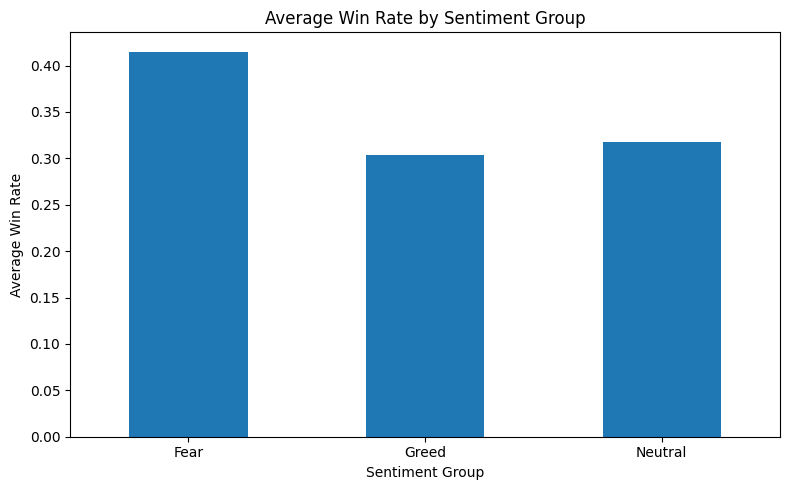

In [51]:
plt.figure(figsize=(8, 5))
performance_by_sentiment["win_rate"].plot(kind="bar")

plt.title("Average Win Rate by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Win Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

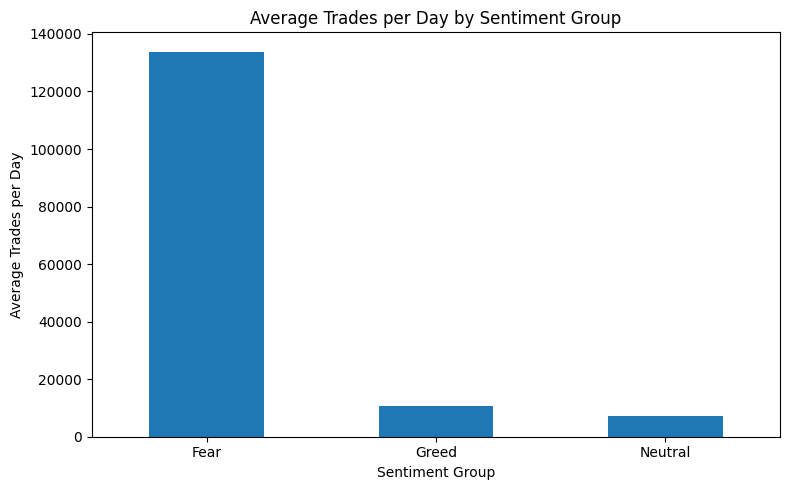

In [52]:
plt.figure(figsize=(8, 5))
performance_by_sentiment["trades_per_day"].plot(kind="bar")

plt.title("Average Trades per Day by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Trades per Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

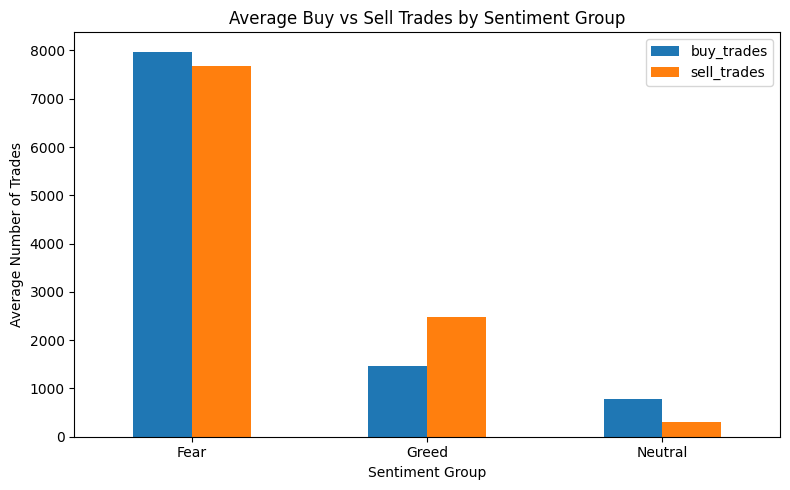

In [53]:
buy_sell_plot = behavior_by_sentiment[["buy_trades", "sell_trades"]]

buy_sell_plot.plot(kind="bar", figsize=(8, 5))

plt.title("Average Buy vs Sell Trades by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Number of Trades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
print("Performance summary by sentiment group:")
display(performance_by_sentiment)

print("Behavior summary by sentiment group:")
display(behavior_by_sentiment)

Performance summary by sentiment group:


,total_daily_pnl,avg_pnl_per_trade,win_rate,trades_per_day
sentiment_group,,,,
Fear,6.699925e+06,50.0476,0.4151,133871.00
Greed,8.416455e+05,29.0180,0.3041,10812.75
Neutral,1.587424e+05,22.2297,0.3172,7141.00


Behavior summary by sentiment group:


,avg_trade_size_usd,avg_fee,buy_trades,sell_trades,buy_sell_ratio
sentiment_group,,,,,
Fear,5259.9778,1.0833,7977.0,7687.0,1.0377
Greed,4956.6798,1.0660,1473.5,2477.0,0.8819
Neutral,3058.8481,1.2245,786.0,295.0,2.6644


In [55]:
comparison_view = analysis_df[[
    "date_only",
    "sentiment_group",
    "classification",
    "total_daily_pnl",
    "avg_pnl_per_trade",
    "win_rate",
    "trades_per_day",
    "avg_trade_size_usd",
    "buy_trades",
    "sell_trades",
    "buy_sell_ratio"
]].sort_values("date_only")

print("Day-level comparison table:")
display(comparison_view)

Day-level comparison table:


,date_only,sentiment_group,classification,total_daily_pnl,avg_pnl_per_trade,win_rate,trades_per_day,avg_trade_size_usd,buy_trades,sell_trades,buy_sell_ratio
0,2023-03-28,Greed,Greed,0.000000e+00,0.000000,0.000000,3,159.000000,0,0,NaN
1,2023-11-14,Greed,Greed,1.555034e+02,0.148807,0.274641,1045,11057.827522,0,0,NaN
2,2024-03-09,Greed,Extreme Greed,1.769655e+05,25.418772,0.490089,6962,5660.265764,88,75,1.173333
3,2024-07-03,Neutral,Neutral,1.587424e+05,22.229713,0.317182,7141,3058.848110,786,295,2.664407
4,2024-10-27,Greed,Greed,3.189461e+06,90.504272,0.451605,35241,2949.625864,5806,9833,0.590461
5,2025-02-19,Fear,Fear,6.699925e+06,50.047622,0.415146,133871,5259.977837,7977,7687,1.037726


In [56]:
for sentiment in analysis_df["sentiment_group"].dropna().unique():
    subset = analysis_df[analysis_df["sentiment_group"] == sentiment]
    print(f"\n--- {sentiment} ---")
    print("Days:", len(subset))
    print("Average total daily PnL:", round(subset["total_daily_pnl"].mean(), 4))
    print("Average PnL per trade:", round(subset["avg_pnl_per_trade"].mean(), 4))
    print("Average win rate:", round(subset["win_rate"].mean(), 4))
    print("Average trades per day:", round(subset["trades_per_day"].mean(), 4))
    print("Average trade size (USD):", round(subset["avg_trade_size_usd"].mean(), 4))
    print("Average buy trades:", round(subset["buy_trades"].mean(), 4))
    print("Average sell trades:", round(subset["sell_trades"].mean(), 4))
    print("Average buy/sell ratio:", round(subset["buy_sell_ratio"].mean(), 4))


--- Greed ---
Days: 4
Average total daily PnL: 841645.5068
Average PnL per trade: 29.018
Average win rate: 0.3041
Average trades per day: 10812.75
Average trade size (USD): 4956.6798
Average buy trades: 1473.5
Average sell trades: 2477.0
Average buy/sell ratio: 0.8819

--- Neutral ---
Days: 1
Average total daily PnL: 158742.3781
Average PnL per trade: 22.2297
Average win rate: 0.3172
Average trades per day: 7141.0
Average trade size (USD): 3058.8481
Average buy trades: 786.0
Average sell trades: 295.0
Average buy/sell ratio: 2.6644

--- Fear ---
Days: 1
Average total daily PnL: 6699925.1906
Average PnL per trade: 50.0476
Average win rate: 0.4151
Average trades per day: 133871.0
Average trade size (USD): 5259.9778
Average buy trades: 7977.0
Average sell trades: 7687.0
Average buy/sell ratio: 1.0377


In [57]:
trader_daily = (
    hist_aligned.groupby(["date_only", "Account"])
    .agg(
        trader_daily_pnl=("Closed PnL", "sum"),
        trader_avg_pnl_per_trade=("Closed PnL", "mean"),
        trader_win_rate=("is_win", "mean"),
        trader_avg_trade_size_usd=("Size USD", "mean"),
        trader_trades_per_day=("Closed PnL", "count")
    )
    .reset_index()
)

print("Trader-level daily table created successfully")
display(trader_daily.head(10))

Trader-level daily table created successfully


,date_only,Account,trader_daily_pnl,trader_avg_pnl_per_trade,trader_win_rate,trader_avg_trade_size_usd,trader_trades_per_day
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.000000,159.000000,3
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.000000,23066.935000,2
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,0.149092,0.275168,11034.799511,1043
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,-206.074672,0.333333,3048.594444,27
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,0.000000,0.000000,1136.312727,88
5,2024-03-09,0x4f93fead39b70a1824f981a54d4e55b278e9f760,-7919.471032,-10.848590,0.306849,6219.798493,730
6,2024-03-09,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,187842.084190,61.769840,0.824071,3677.809106,3041
7,2024-03-09,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2606.894756,0.847495,0.218791,7639.724412,3076
8,2024-07-03,0x271b280974205ca63b716753467d5a371de622ab,-1.000000,-0.200000,0.000000,6070.200000,5
9,2024-07-03,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,215.754798,2.696935,0.100000,767.247750,80


In [58]:
trader_summary = (
    trader_daily.groupby("Account")
    .agg(
        total_pnl=("trader_daily_pnl", "sum"),
        avg_daily_pnl=("trader_daily_pnl", "mean"),
        avg_win_rate=("trader_win_rate", "mean"),
        avg_trade_size_usd=("trader_avg_trade_size_usd", "mean"),
        avg_trades_per_day=("trader_trades_per_day", "mean"),
        active_days=("date_only", "nunique")
    )
    .reset_index()
)

print("Trader summary table created successfully")
display(trader_summary.head(10))

Trader summary table created successfully


,Account,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,800114.909989,0.215758,15578.066879,1909.000000,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,18853.086574,0.483146,2093.050795,1926.500000,2
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,10587.696144,0.410153,16282.920323,382.000000,3
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,66157.740843,0.438246,508.413964,6633.000000,2
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,84313.992027,0.504117,3073.413160,1617.000000,2
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-2.770457e+04,-4617.427907,0.194149,5212.250799,102.833333,6
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1.445692e+04,7228.459668,0.423541,4677.615483,1794.500000,2
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,5.349625e+04,26748.123621,0.486948,3562.323166,166.000000,2
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05,99752.796366,0.230093,5522.192161,191.500000,2
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,104135.468085,0.579597,3111.662097,262.750000,4


In [59]:
trade_freq_threshold = trader_summary["avg_trades_per_day"].median()

trader_summary["frequency_segment"] = np.where(
    trader_summary["avg_trades_per_day"] > trade_freq_threshold,
    "Frequent",
    "Infrequent"
)

print("Frequency segment created successfully")
print("Median avg_trades_per_day:", round(trade_freq_threshold, 4))
print("\nFrequency segment counts:")
print(trader_summary["frequency_segment"].value_counts())

Frequency segment created successfully
Median avg_trades_per_day: 1585.5

Frequency segment counts:
frequency_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64


In [60]:
win_rate_threshold = trader_summary["avg_win_rate"].median()

trader_summary["consistency_segment"] = np.where(
    trader_summary["avg_win_rate"] > win_rate_threshold,
    "Consistent Winners",
    "Inconsistent"
)

print("Consistency segment created successfully")
print("Median avg_win_rate:", round(win_rate_threshold, 4))
print("\nConsistency segment counts:")
print(trader_summary["consistency_segment"].value_counts())

Consistency segment created successfully
Median avg_win_rate: 0.4105

Consistency segment counts:
consistency_segment
Inconsistent          16
Consistent Winners    16
Name: count, dtype: int64


In [61]:
size_threshold = trader_summary["avg_trade_size_usd"].median()

trader_summary["size_segment"] = np.where(
    trader_summary["avg_trade_size_usd"] > size_threshold,
    "High Size",
    "Low Size"
)

print("Size segment created successfully")
print("Median avg_trade_size_usd:", round(size_threshold, 4))
print("\nSize segment counts:")
print(trader_summary["size_segment"].value_counts())

Size segment created successfully
Median avg_trade_size_usd: 3511.5293

Size segment counts:
size_segment
High Size    16
Low Size     16
Name: count, dtype: int64


In [62]:
print("Trader summary with segments:")
display(
    trader_summary[[
        "Account",
        "total_pnl",
        "avg_daily_pnl",
        "avg_win_rate",
        "avg_trade_size_usd",
        "avg_trades_per_day",
        "active_days",
        "frequency_segment",
        "consistency_segment",
        "size_segment"
    ]].head(10)
)

Trader summary with segments:


,Account,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days,frequency_segment,consistency_segment,size_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,800114.909989,0.215758,15578.066879,1909.000000,2,Frequent,Inconsistent,High Size
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,18853.086574,0.483146,2093.050795,1926.500000,2,Frequent,Consistent Winners,Low Size
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,10587.696144,0.410153,16282.920323,382.000000,3,Infrequent,Inconsistent,High Size
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,66157.740843,0.438246,508.413964,6633.000000,2,Frequent,Consistent Winners,Low Size
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,84313.992027,0.504117,3073.413160,1617.000000,2,Frequent,Consistent Winners,Low Size
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-2.770457e+04,-4617.427907,0.194149,5212.250799,102.833333,6,Infrequent,Inconsistent,High Size
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1.445692e+04,7228.459668,0.423541,4677.615483,1794.500000,2,Frequent,Consistent Winners,High Size
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,5.349625e+04,26748.123621,0.486948,3562.323166,166.000000,2,Infrequent,Consistent Winners,High Size
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05,99752.796366,0.230093,5522.192161,191.500000,2,Infrequent,Inconsistent,High Size
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,104135.468085,0.579597,3111.662097,262.750000,4,Infrequent,Consistent Winners,Low Size


In [63]:
frequency_segment_summary = (
    trader_summary.groupby("frequency_segment")[[
        "total_pnl",
        "avg_daily_pnl",
        "avg_win_rate",
        "avg_trade_size_usd",
        "avg_trades_per_day",
        "active_days"
    ]]
    .mean()
    .round(4)
)

print("Performance summary: Frequent vs Infrequent traders")
display(frequency_segment_summary)

Performance summary: Frequent vs Infrequent traders


,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days
frequency_segment,,,,,,
Frequent,486089.3374,223699.5585,0.4046,6399.2394,5305.1198,2.3750
Infrequent,152988.7623,69935.3299,0.3541,4930.4833,625.7865,2.4375


In [64]:
consistency_segment_summary = (
    trader_summary.groupby("consistency_segment")[[
        "total_pnl",
        "avg_daily_pnl",
        "avg_win_rate",
        "avg_trade_size_usd",
        "avg_trades_per_day",
        "active_days"
    ]]
    .mean()
    .round(4)
)

print("Performance summary: Consistent Winners vs Inconsistent traders")
display(consistency_segment_summary)

Performance summary: Consistent Winners vs Inconsistent traders


,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days
consistency_segment,,,,,,
Consistent Winners,267787.0619,151521.2105,0.4910,4928.6941,3990.9844,2.1250
Inconsistent,371291.0379,142113.6779,0.2678,6401.0286,1939.9219,2.6875


In [65]:
size_segment_summary = (
    trader_summary.groupby("size_segment")[[
        "total_pnl",
        "avg_daily_pnl",
        "avg_win_rate",
        "avg_trade_size_usd",
        "avg_trades_per_day",
        "active_days"
    ]]
    .mean()
    .round(4)
)

print("Performance summary: High Size vs Low Size traders")
display(size_segment_summary)

Performance summary: High Size vs Low Size traders


,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days
size_segment,,,,,,
High Size,386146.4110,151509.2855,0.3366,9199.3907,1484.8490,2.5000
Low Size,252931.6887,142125.6030,0.4222,2130.3320,4446.0573,2.3125


In [66]:
print("1) Frequent vs Infrequent traders")
display(frequency_segment_summary)

print("2) Consistent Winners vs Inconsistent traders")
display(consistency_segment_summary)

print("3) High Size vs Low Size traders")
display(size_segment_summary)

1) Frequent vs Infrequent traders


,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days
frequency_segment,,,,,,
Frequent,486089.3374,223699.5585,0.4046,6399.2394,5305.1198,2.3750
Infrequent,152988.7623,69935.3299,0.3541,4930.4833,625.7865,2.4375


2) Consistent Winners vs Inconsistent traders


,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days
consistency_segment,,,,,,
Consistent Winners,267787.0619,151521.2105,0.4910,4928.6941,3990.9844,2.1250
Inconsistent,371291.0379,142113.6779,0.2678,6401.0286,1939.9219,2.6875


3) High Size vs Low Size traders


,total_pnl,avg_daily_pnl,avg_win_rate,avg_trade_size_usd,avg_trades_per_day,active_days
size_segment,,,,,,
High Size,386146.4110,151509.2855,0.3366,9199.3907,1484.8490,2.5000
Low Size,252931.6887,142125.6030,0.4222,2130.3320,4446.0573,2.3125


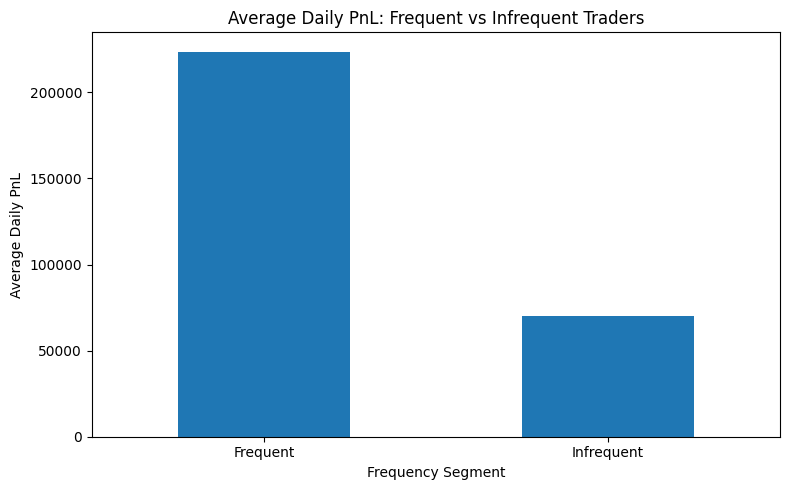

In [67]:
plt.figure(figsize=(8, 5))
frequency_segment_summary["avg_daily_pnl"].plot(kind="bar")

plt.title("Average Daily PnL: Frequent vs Infrequent Traders")
plt.xlabel("Frequency Segment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

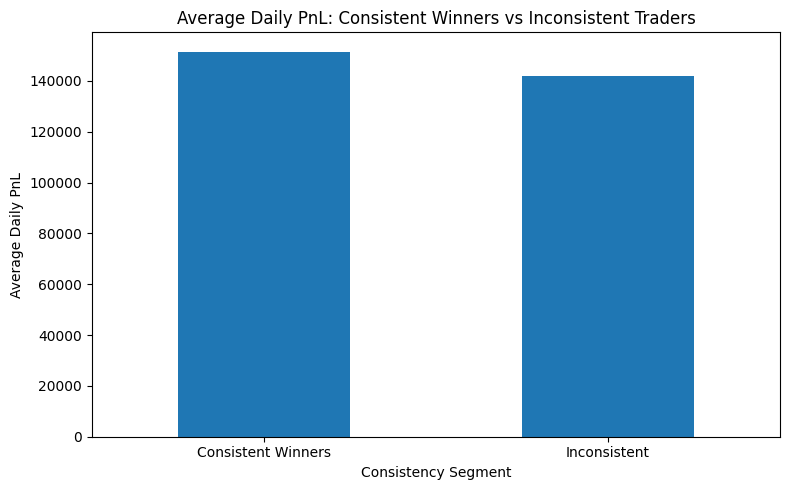

In [68]:
plt.figure(figsize=(8, 5))
consistency_segment_summary["avg_daily_pnl"].plot(kind="bar")

plt.title("Average Daily PnL: Consistent Winners vs Inconsistent Traders")
plt.xlabel("Consistency Segment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

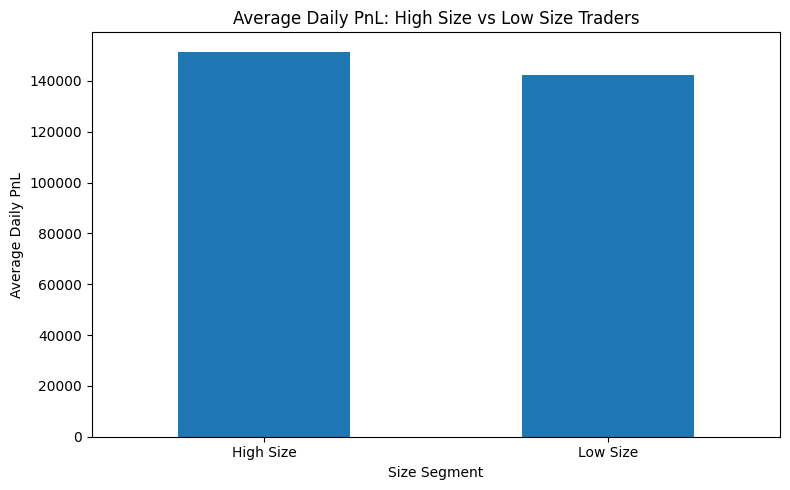

In [69]:
plt.figure(figsize=(8, 5))
size_segment_summary["avg_daily_pnl"].plot(kind="bar")

plt.title("Average Daily PnL: High Size vs Low Size Traders")
plt.xlabel("Size Segment")
plt.ylabel("Average Daily PnL")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [70]:
print("Observation 1:")
print("Compare Fear vs Greed vs Neutral using the performance and behavior summary tables above.")

print("\nObservation 2:")
print("Compare Frequent vs Infrequent traders using the frequency segment summary and chart.")

print("\nObservation 3:")
print("Compare Consistent Winners vs Inconsistent OR High Size vs Low Size traders using the segment summaries and charts.")

Observation 1:
Compare Fear vs Greed vs Neutral using the performance and behavior summary tables above.

Observation 2:
Compare Frequent vs Infrequent traders using the frequency segment summary and chart.

Observation 3:
Compare Consistent Winners vs Inconsistent OR High Size vs Low Size traders using the segment summaries and charts.


In [71]:
print(" Performance by Sentiment ")
print(performance_by_sentiment.to_string())

print("\nBehavior by Sentiment")
print(behavior_by_sentiment.to_string())

print("\nFrequency Segment Summary")
print(frequency_segment_summary.to_string())

print("\n Consistency Segment Summary ")
print(consistency_segment_summary.to_string())

print("\n Size Segment Summary ")
print(size_segment_summary.to_string())

 Performance by Sentiment 
                 total_daily_pnl  avg_pnl_per_trade  win_rate  trades_per_day
sentiment_group                                                              
Fear                6.699925e+06            50.0476    0.4151       133871.00
Greed               8.416455e+05            29.0180    0.3041        10812.75
Neutral             1.587424e+05            22.2297    0.3172         7141.00

Behavior by Sentiment
                 avg_trade_size_usd  avg_fee  buy_trades  sell_trades  buy_sell_ratio
sentiment_group                                                                      
Fear                      5259.9778   1.0833      7977.0       7687.0          1.0377
Greed                     4956.6798   1.0660      1473.5       2477.0          0.8819
Neutral                   3058.8481   1.2245       786.0        295.0          2.6644

Frequency Segment Summary
                     total_pnl  avg_daily_pnl  avg_win_rate  avg_trade_size_usd  avg_trades_per_day  ac

In [72]:
print("Observation 1:")
print(
    "Fear days showed the strongest performance in this aligned sample. "
    "Average total daily PnL was about 6.70M on Fear days, compared with about 0.84M on Greed days "
    "and about 0.16M on Neutral days. Fear days also had the highest average PnL per trade (50.0476) "
    "and the highest win rate (0.4151)."
)

print("\nObservation 2:")
print(
    "Trader behavior also changed across sentiment conditions. Fear days had the highest average trade size "
    "(about 5259.98 USD) and the highest activity level (about 133871 trades per day). "
    "Greed days were more sell-heavy, with a buy/sell ratio below 1 (0.8819), while Neutral days were the most buy-heavy "
    "with a buy/sell ratio of 2.6644."
)

print("\nObservation 3:")
print(
    "Trader segmentation revealed clear differences. Frequent traders outperformed infrequent traders, "
    "with higher average daily PnL (223699.5585 vs 69935.3299) and higher win rate (0.4046 vs 0.3541). "
    "Consistent Winners had a much higher average win rate (0.4910 vs 0.2678), while High Size traders generated slightly "
    "higher average daily PnL than Low Size traders (151509.2855 vs 142125.6030) but had a lower win rate (0.3366 vs 0.4222)."
)

Observation 1:
Fear days showed the strongest performance in this aligned sample. Average total daily PnL was about 6.70M on Fear days, compared with about 0.84M on Greed days and about 0.16M on Neutral days. Fear days also had the highest average PnL per trade (50.0476) and the highest win rate (0.4151).

Observation 2:
Trader behavior also changed across sentiment conditions. Fear days had the highest average trade size (about 5259.98 USD) and the highest activity level (about 133871 trades per day). Greed days were more sell-heavy, with a buy/sell ratio below 1 (0.8819), while Neutral days were the most buy-heavy with a buy/sell ratio of 2.6644.

Observation 3:
Trader segmentation revealed clear differences. Frequent traders outperformed infrequent traders, with higher average daily PnL (223699.5585 vs 69935.3299) and higher win rate (0.4046 vs 0.3541). Consistent Winners had a much higher average win rate (0.4910 vs 0.2678), while High Size traders generated slightly higher average

## Round 4 Summary — Analysis and Insights

### Performance by Sentiment
- Fear days showed the strongest performance in the aligned sample.
- Fear days had the highest average total daily PnL, highest average PnL per trade, and highest win rate.
- Greed and Neutral days showed weaker average profitability than Fear days.

### Behavior by Sentiment
- Fear days also showed the highest trading activity and the largest average trade size.
- Greed days were relatively more sell-heavy, with a buy/sell ratio below 1.
- Neutral days were the most buy-heavy in this sample.

### Trader Segmentation
Three simple trader segments were created:
- Frequent vs Infrequent traders
- Consistent Winners vs Inconsistent traders
- High Size vs Low Size traders

### Segment Findings
- Frequent traders outperformed infrequent traders on both average daily PnL and win rate.
- Consistent Winners had a much higher average win rate than Inconsistent traders.
- High Size traders had slightly higher average daily PnL than Low Size traders, but their average win rate was lower.

### Important Note
The overlap between the sentiment dataset and trader dataset is limited, so these findings should be treated as sample-based directional insights rather than broad market-wide conclusions.

In [73]:
print("Strategy Idea 1:")
print(
    "On Fear days, traders may allow higher participation because this sample shows the strongest daily PnL, "
    "highest PnL per trade, and highest win rate under Fear conditions. However, this should still be applied "
    "with controlled risk because the conclusion is based on a limited overlapping sample."
)

print("\nStrategy Idea 2:")
print(
    "On Greed days, traders may use more caution and avoid blindly increasing exposure. In this sample, Greed days "
    "showed lower win rate, lower PnL per trade, and a more sell-heavy profile. A practical rule of thumb would be "
    "to reduce position aggressiveness on Greed days unless other trade-quality signals are strong."
)

Strategy Idea 1:
On Fear days, traders may allow higher participation because this sample shows the strongest daily PnL, highest PnL per trade, and highest win rate under Fear conditions. However, this should still be applied with controlled risk because the conclusion is based on a limited overlapping sample.

Strategy Idea 2:
On Greed days, traders may use more caution and avoid blindly increasing exposure. In this sample, Greed days showed lower win rate, lower PnL per trade, and a more sell-heavy profile. A practical rule of thumb would be to reduce position aggressiveness on Greed days unless other trade-quality signals are strong.


In [74]:
print("Strategy Idea 3:")
print(
    "Trader segmentation suggests that frequent traders performed better than infrequent traders in this sample, "
    "with higher average daily PnL and higher win rate. A practical rule of thumb is to allow higher activity only "
    "for traders or strategies that already show stable execution quality, while lower-performing or inconsistent "
    "traders should avoid increasing trade frequency just because market sentiment changes."
)

Strategy Idea 3:
Trader segmentation suggests that frequent traders performed better than infrequent traders in this sample, with higher average daily PnL and higher win rate. A practical rule of thumb is to allow higher activity only for traders or strategies that already show stable execution quality, while lower-performing or inconsistent traders should avoid increasing trade frequency just because market sentiment changes.


## Round 5 — Actionable Strategy Recommendations

### Strategy Idea 1 — Stronger participation on Fear days
In this aligned sample, Fear days showed the strongest average total daily PnL, the highest average PnL per trade, and the highest win rate.  
A practical rule of thumb is to allow higher trading participation on Fear days, but still with controlled risk because the overlap period is limited.

### Strategy Idea 2 — More caution on Greed days
Greed days showed weaker profitability metrics than Fear days and appeared more sell-heavy in this sample.  
A practical rule of thumb is to avoid blindly increasing exposure on Greed days and instead require stronger trade-quality confirmation before taking larger positions.

### Strategy Idea 3 — Increase activity only for stronger trader profiles
Trader segmentation showed that Frequent traders outperformed Infrequent traders, while more consistent traders had stronger win-rate characteristics.  
A practical rule of thumb is to increase trade frequency only for traders or strategies that already demonstrate stable execution quality, while weaker or inconsistent profiles should remain selective.

### Caution on interpretation
These recommendations are based on the overlapping dates available in both datasets.  
Because the aligned sample size is limited, the findings should be interpreted as directional insights rather than universal trading rules.  
A larger date overlap and additional market variables would make the recommendations more robust.

In [78]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
c:\Users\anany\OneDrive\Desktop\primetrade-sentiment-analysis\notebooks

Files/folders here:
['analysis.ipynb']


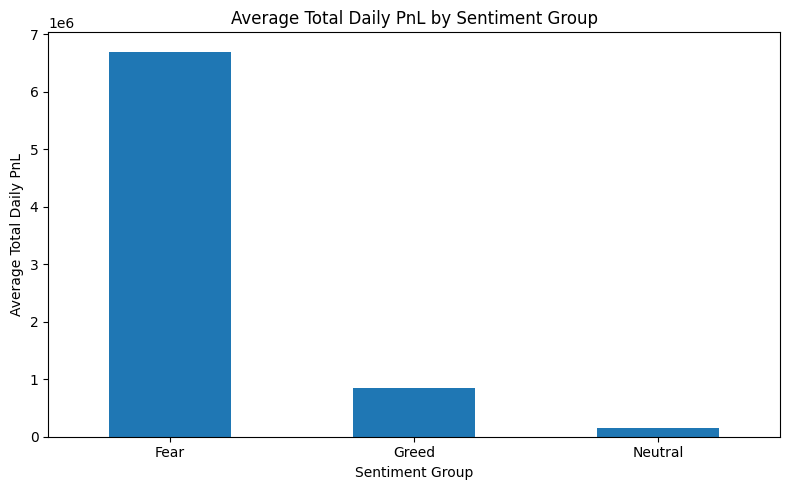

In [80]:
plt.figure(figsize=(8, 5))
performance_by_sentiment["total_daily_pnl"].plot(kind="bar")

plt.title("Average Total Daily PnL by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Total Daily PnL")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/charts/avg_total_daily_pnl_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

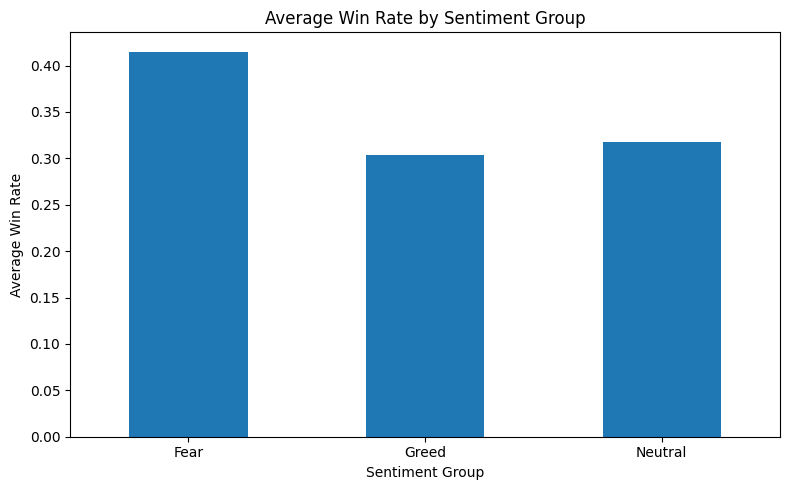

In [81]:
plt.figure(figsize=(8, 5))
performance_by_sentiment["win_rate"].plot(kind="bar")

plt.title("Average Win Rate by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Win Rate")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/charts/avg_win_rate_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

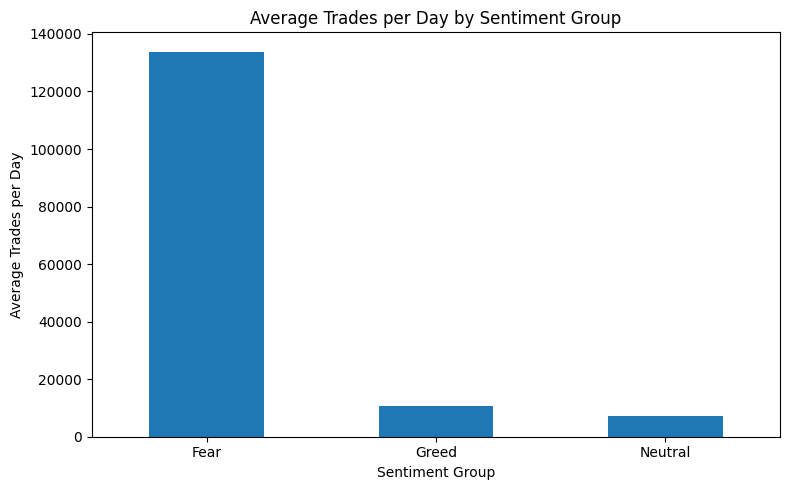

In [82]:
plt.figure(figsize=(8, 5))
performance_by_sentiment["trades_per_day"].plot(kind="bar")

plt.title("Average Trades per Day by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Trades per Day")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/charts/avg_trades_per_day_by_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

In [84]:
analysis_df.to_csv("../data/processed/final_analysis_table.csv", index=False)
print("final_analysis_table.csv saved successfully")

final_analysis_table.csv saved successfully


In [85]:
performance_by_sentiment.to_csv("../outputs/tables/performance_by_sentiment.csv")
print("performance_by_sentiment.csv saved successfully")

performance_by_sentiment.csv saved successfully


In [86]:
behavior_by_sentiment.to_csv("../outputs/tables/behavior_by_sentiment.csv")
print("behavior_by_sentiment.csv saved successfully")

behavior_by_sentiment.csv saved successfully
